## 1.1) Data loading and data information

In [98]:
# import libraries
import gdown
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt


In [78]:
# import dataset
# Google Drive file ID
file_id = "1XZianrb-YFsa4uVxcXJCVjNcVE2ceMAc"

# Correct download URL format
url = f"https://drive.google.com/uc?id={file_id}"

# Local filename
filename = "diabetes_prediction_dataset.csv"

# Download the file
data = gdown.download(url=url, output=filename, quiet=False)

print("Download completed:", data)

Downloading...
From: https://drive.google.com/uc?id=1XZianrb-YFsa4uVxcXJCVjNcVE2ceMAc
To: c:\Users\MANEL\Documents\data-analytics\machine-learning\ML2\projet_2\diabetes_prediction_dataset.csv
100%|██████████| 3.81M/3.81M [00:06<00:00, 582kB/s]

Download completed: diabetes_prediction_dataset.csv


In [79]:
# check the data
df = pd.read_csv(data)
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [80]:
#data dimensions
df.shape



(100000, 9)

In [81]:
# types data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [82]:
# statistics describe
df[["age", "hypertension", "bmi", "HbA1c_level", "blood_glucose_level"]].describe()

,age,hypertension,bmi,HbA1c_level,blood_glucose_level
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,27.320767,5.527507,138.058060
std,22.516840,0.26315,6.636783,1.070672,40.708136
min,0.080000,0.00000,10.010000,3.500000,80.000000
25%,24.000000,0.00000,23.630000,4.800000,100.000000
50%,43.000000,0.00000,27.320000,5.800000,140.000000
75%,60.000000,0.00000,29.580000,6.200000,159.000000
max,80.000000,1.00000,95.690000,9.000000,300.000000


In [83]:
# missing values
df.isnull().sum()
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

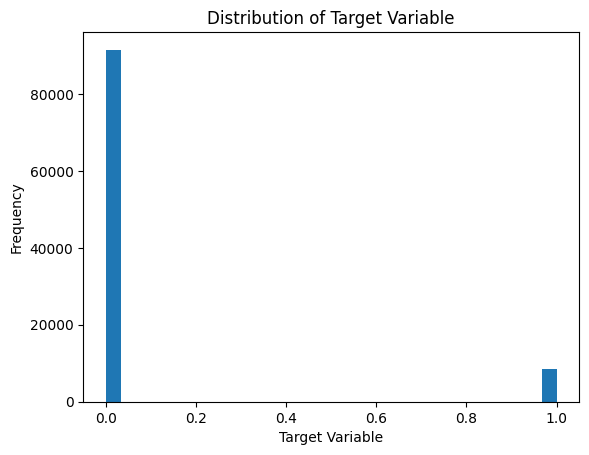

In [84]:
# plot the distribution of the target variable

plt.hist(df["diabetes"], bins=30)
plt.xlabel("Target Variable")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")
plt.show()

## 1.2) Data preparation

In [85]:
# modified categorical data into numerical data in one hot encoding
df_ohe = pd.get_dummies(df, columns=["smoking_history", "gender"])
df_ohe.head()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Female,gender_Male,gender_Other
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,True,False,True,False,False
1,54.0,0,0,27.32,6.6,80,0,True,False,False,False,False,False,True,False,False
2,28.0,0,0,27.32,5.7,158,0,False,False,False,False,True,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,True,False,False,False,False,True,False,False
4,76.0,1,1,20.14,4.8,155,0,False,True,False,False,False,False,False,True,False


In [86]:
# target and features
col_target = "diabetes"
col_features = [c for c in df_ohe.columns if c != col_target]

features = np.array(df_ohe[col_features], dtype="float16")
target = np.array(df_ohe[col_target], dtype="uint8")

print(f"features shape : {features.shape}")
print(f"targets shape: {target.shape}")

features shape : (100000, 15)
targets shape: (100000,)


In [87]:
# regression model

In [94]:
# split the data into training and validation sets
train, val, train_targets, val_targets = train_test_split(
    features, target, test_size=0.2, random_state=42
)

print(f"number of train : {train.shape[0]}")
print(f"number or validation: {val.shape[0]}")
print(f"number of train target : {train_targets.shape[0]}")
print(f"number of validation target : {val_targets.shape[0]}")



number of train : 80000
number or validation: 20000
number of train target : 80000
number of validation target : 20000


In [92]:
number_positive = np.sum(train_targets)
total_samples = len(train_targets)
percentage_positive = (number_positive / total_samples)
print(f"percentage of positive samples in the training set: {percentage_positive:.2%}")
print(f"number of positive : {number_positive}")
print(f"total number of samples: {total_samples}")


percentage of positive samples in the training set: 8.49%
number of positive : 6792
total number of samples: 80000


In [95]:
# standardisation of the data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

In [99]:
# Logistic regression model
model = LogisticRegression()
model.fit(train_scaled, train_targets)
# evaluate the model
accuracy = model.score(val_scaled, val_targets)
print(f"accuracy of the model: {accuracy:.2%}")

accuracy of the model: 95.90%
